## Representations of plume front shape during initial discharge

_N.B. figure comprised of both photos and figures so will be compiled in adobe illustrator_

In [1]:
# imports
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Use given style
plt.style.use("james2026lock.mplstyle")

# load experiment table
metadata = pd.read_csv("../../data/metadata/metadata.csv")
folder = "../../data/datafiles"

In [2]:
# define function to plot experiment data


def plot_experiment(ax, row, folder, vmin=0, vmax=0.65, cmap="viridis"):
    """
    Plot experiment data (height vs x and time) into a given axis.

    Parameters
    ----------
    ax : matplotlib.axes.Axes
        Axis to plot into.
    row : pd.Series or namedtuple
        A row from the dataframe with fields:
        - exp_code
        - file_name
        - rho
        - C0 (optional, if you want to annotate)
    folder : str
        Path to folder with .npy files.
    h0, l0 : float
        Characteristic scales (height and length).
    rho_water : float
        Reference density.
    vmin, vmax : float, optional
        Colorbar scaling.
    cmap : str, optional
        Colormap.
    """

    # constants
    h0 = 0.25
    l0 = 0.27

    filename = folder + "/" + row.exp_code + ".npy"
    data = np.load(filename, allow_pickle=True).item()

    # Normalize variables
    height = np.abs(data["height_m"]) / h0
    height[height == 0] = np.nan
    x = np.abs(data["xcenters"]) / l0

    # Reduced gravity scaling
    t_0 = l0 / row["u_c"]

    t = np.abs(data["time_s"]) / t_0

    # Define extent for imshow
    extent = [x[0], x[-1], t[0], t[-1]]

    im = ax.imshow(
        height.T,
        extent=extent,
        aspect="auto",
        vmin=vmin,
        vmax=vmax,
        cmap=cmap,
        origin="lower",
    )

    return im

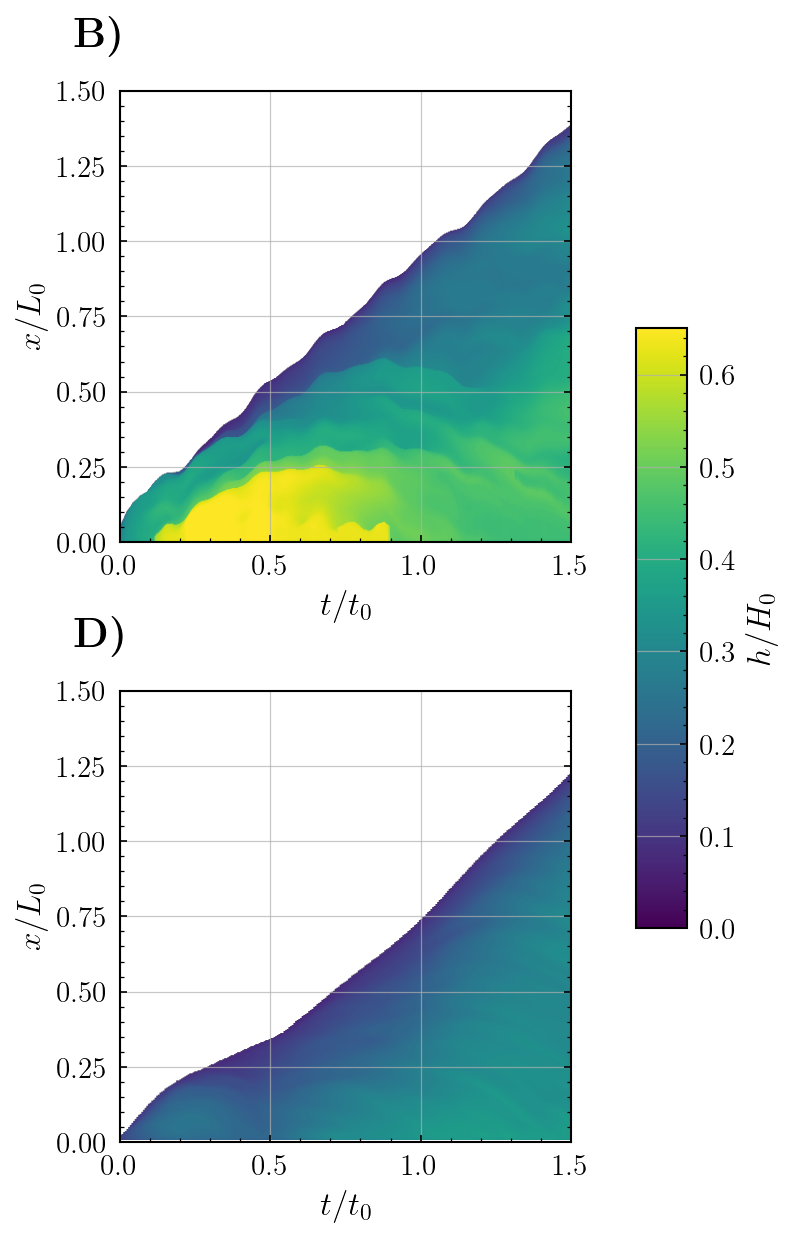

In [3]:
# Select experiments to plot
exp_codes = ["JH1", "JH7"]
rows = metadata.loc[metadata["exp_code"].isin(exp_codes)]

# Set up figure and axes
fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(4.3, 8), constrained_layout=True)

# Manually position the two square axes
for i, ax in enumerate(axs.flat):
    ax.set_position([0.12, 0.53 - i * 0.5, 0.7, 0.44])

# Plot each experiment
for ax, (_, row) in zip(axs.flat, rows.iterrows()):
    im = plot_experiment(ax, row, folder)

# Manually place a colorbar axis centred on the right, height matching one panel
cbar_ax = fig.add_axes([0.92, 0.24, 0.08, 0.5])  # [left, bottom, width, height]
fig.colorbar(im, cax=cbar_ax, label=r"$h/H_0$")

# Common axis formatting
lim = 1.5
for ax in axs.flat:
    ax.set_xlim([0, lim])
    ax.set_ylim([0, lim])
    ax.set_box_aspect(1)
    ax.set_xlabel(r"$t/t_0$")
    ax.set_ylabel(r"$x/L_0$")

for axis, label in zip(axs.flat, ["\\textbf{B)}", "\\textbf{D)}"]):
    axis.annotate(
        label,
        xy=(-0.1, 1.1),
        xycoords="axes fraction",
        fontsize=20,
        fontweight="bold",
    )

plt.savefig(
    "../figures/figure_7_RHS.pdf", format="pdf", bbox_inches="tight", facecolor="white"
)
plt.show()